In [81]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

libpng warning: iCCP: known incorrect sRGB profile


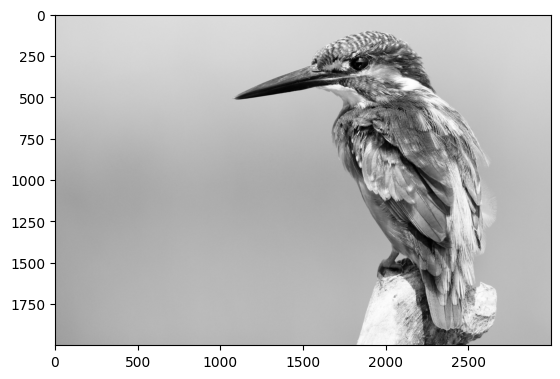

In [82]:
img = cv.imread("../../image_test/bird2.png")
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY) ## Convert it to grayscale
plt.imshow(img, cmap="gray")

In [ ]:
def otsu(img):

    ## calculamos el histograma
    histogram, bins = np.histogram(img, bins=256, range=(0,256))

    ## Normalizamos el histograma
    normalized = histogram/(np.sum(histogram))

    ## Cumulative sums
    P1_k = 0

    P1_k = np.cumsum(normalized) 

    ## Cumulative mean
    mean_k = np.cumsum(normalized * np.arange(256))
    mean_g = mean_k[-1]
    

    inter_variance = ((mean_g * P1_k - mean_k)**2)/(P1_k*(1-P1_k)+1e-10)
    selected_k = np.argmax(inter_variance)


    return selected_k


In [ ]:
k = otsu(img)
k

np.int64(134)

In [216]:
def binarize(img, threshold):

    M, N = img.shape
    result = np.zeros((M, N))

    for x in range(M):
        for y in range(N):
            result[x][y] = 0 if img[x][y] < threshold else 255
    
    return result

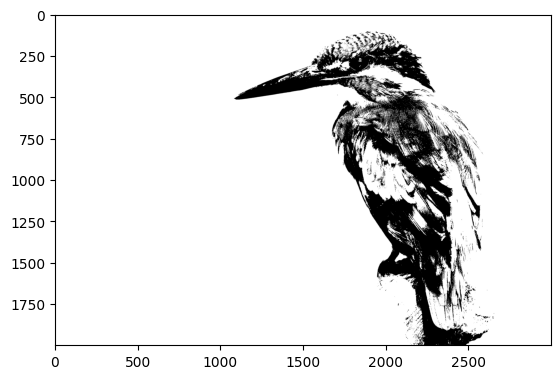

In [217]:
binarized = binarize(img, k)
plt.imshow(binarized, cmap="gray")